# Fase 3, Paso 2 — Reglas simples basadas en indicadores técnicos

Tres reglas clásicas (parámetros no ajustados sobre estos datos, por eso ninguna requiere walk-forward), sobre datos **diarios** reales de SPY:

- **SMA 50/200** — cruce de medias móviles (trend-following).
- **Momentum 12 meses** — time-series momentum (trend-following).
- **RSI(14) 30/70** — sobrecompra/sobreventa (mean-reversion, contrarian).

Buy & Hold se recalcula sobre los mismos datos diarios de SPY para que la comparación sea limpia y exactamente sobre el mismo periodo y fuente.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd

from inversion import data, strategies, backtest, viz

CAPITAL_TOTAL = 10_000.0
FECHA_INICIO_ANALISIS = "2000-01-01"  # igual que el benchmark del Paso 1
SPY_DIARIO_PATH = Path("../data/processed/spy_diario.csv")

## Datos diarios de SPY

Si ya existe `spy_diario.csv` lo reutiliza; si no, lo descarga vía `yfinance` (histórico completo, precio ajustado por dividendos).

In [2]:
if SPY_DIARIO_PATH.exists():
    spy = pd.read_csv(SPY_DIARIO_PATH, parse_dates=["fecha"])
else:
    spy = data.descargar_spy_diario()
    SPY_DIARIO_PATH.parent.mkdir(parents=True, exist_ok=True)
    spy.to_csv(SPY_DIARIO_PATH, index=False)

spy = spy.sort_values("fecha").reset_index(drop=True)
print(f"{len(spy)} días, {spy['fecha'].min().date()} a {spy['fecha'].max().date()}")
spy.tail()

8474 días, 1993-01-29 a 2026-09-29


,fecha,apertura,maximo,minimo,cierre,volumen
8469,2026-09-23,772.789978,773.049988,766.500000,767.809998,54931700
8470,2026-09-24,764.070007,768.950012,763.250000,767.179993,43983700
8471,2026-09-25,768.780029,772.280029,766.289978,771.349976,36666700
8472,2026-09-28,768.349976,769.539978,763.719971,765.609985,42296700
8473,2026-09-29,766.830017,766.950012,762.570007,763.260010,14739885


## SMA 50/200

Invertido cuando SMA(50) > SMA(200). Señal del día *t* ejecutada en el retorno del día *t+1* (anti look-ahead bias) — mismo criterio en las tres estrategias.

In [3]:
señal_sma = strategies.señal_sma(spy)
df_sma = backtest.recortar_periodo(spy, señal_sma, FECHA_INICIO_ANALISIS)
df_sma, valor_sma = backtest.simular(df_sma, CAPITAL_TOTAL)

señal_bh = strategies.señal_buy_and_hold(spy)
df_bh = backtest.recortar_periodo(spy, señal_bh, FECHA_INICIO_ANALISIS)
df_bh, valor_bh = backtest.simular(df_bh, CAPITAL_TOTAL)

resumen_sma = pd.DataFrame([
    backtest.resumen(df_bh, valor_bh, CAPITAL_TOTAL, "Buy & Hold (SPY, mismos datos)"),
    backtest.resumen(df_sma, valor_sma, CAPITAL_TOTAL, "SMA 50/200"),
])
resumen_sma

,Escenario,Valor final (USD),CAGR,Drawdown máximo,Sharpe (rf=0),Sortino (rf=0),Operaciones,% tiempo invertido
0,"Buy & Hold (SPY, mismos datos)",83960.499077,0.082772,-0.551895,0.510584,0.650008,0,0.999851
1,SMA 50/200,81612.159323,0.081624,-0.337173,0.654399,0.696106,26,0.738290


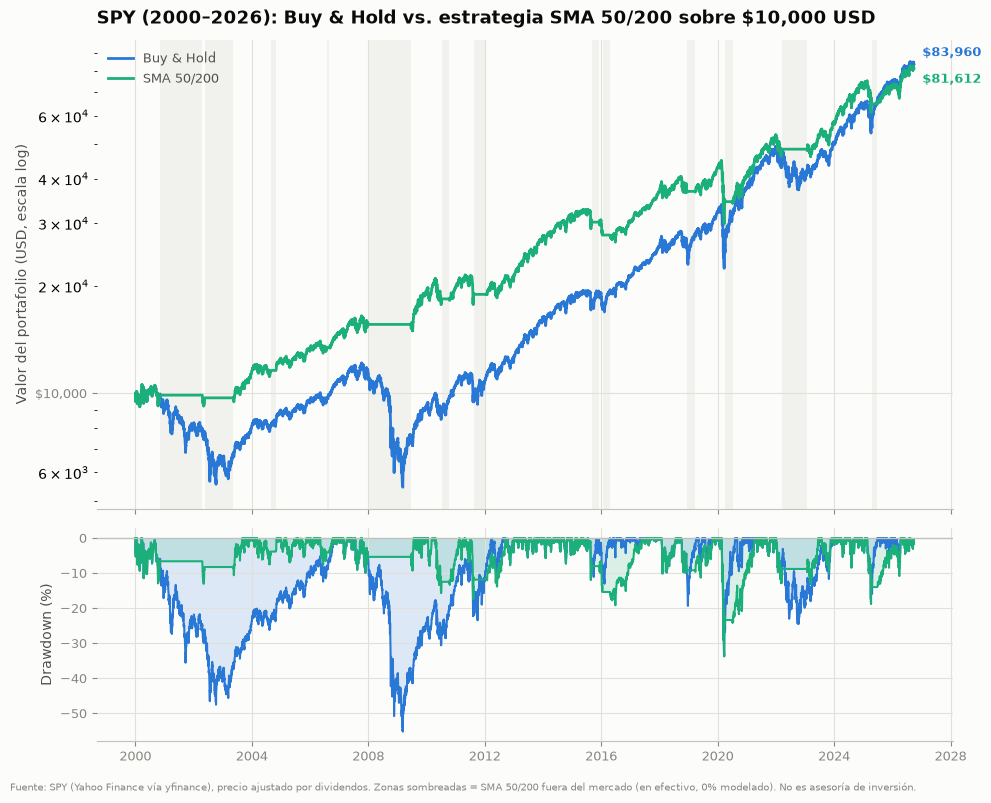

In [4]:
series_sma = pd.DataFrame({
    "fecha": df_sma["fecha"],
    "valor_buy_and_hold": valor_bh.values,
    "valor_sma": valor_sma.values,
    "posicion_sma": df_sma["posicion"].values,
})
series_sma.to_csv("../outputs/series/series_comparacion_sma.csv", index=False)
resumen_sma.to_csv("../outputs/metrics/resumen_metricas_sma.csv", index=False)

viz.graficar_estrategia_vs_benchmark(
    series_sma, "valor_buy_and_hold", "valor_sma", "posicion_sma",
    viz.COLOR_SMA, "SMA 50/200",
    "SPY (2000–2026): Buy & Hold vs. estrategia SMA 50/200 sobre $10,000 USD",
    "../outputs/figures/comparacion_buyhold_vs_sma.png",
)

## Momentum 12 meses

Invertido cuando el retorno de los últimos 252 días de trading (~12 meses) es positivo. Ventana clásica de la literatura de time-series momentum (Moskowitz/Ooi/Pedersen 2012).

In [5]:
señal_momentum = strategies.señal_momentum(spy)
df_momentum = backtest.recortar_periodo(spy, señal_momentum, FECHA_INICIO_ANALISIS)
df_momentum, valor_momentum = backtest.simular(df_momentum, CAPITAL_TOTAL)

resumen_momentum = pd.DataFrame([
    backtest.resumen(df_bh, valor_bh, CAPITAL_TOTAL, "Buy & Hold (SPY, mismos datos)"),
    backtest.resumen(df_momentum, valor_momentum, CAPITAL_TOTAL, "Momentum 12m"),
])
resumen_momentum

,Escenario,Valor final (USD),CAGR,Drawdown máximo,Sharpe (rf=0),Sortino (rf=0),Operaciones,% tiempo invertido
0,"Buy & Hold (SPY, mismos datos)",83960.499077,0.082772,-0.551895,0.510584,0.650008,0,0.999851
1,Momentum 12m,66298.515971,0.073256,-0.311682,0.599340,0.647028,90,0.778885


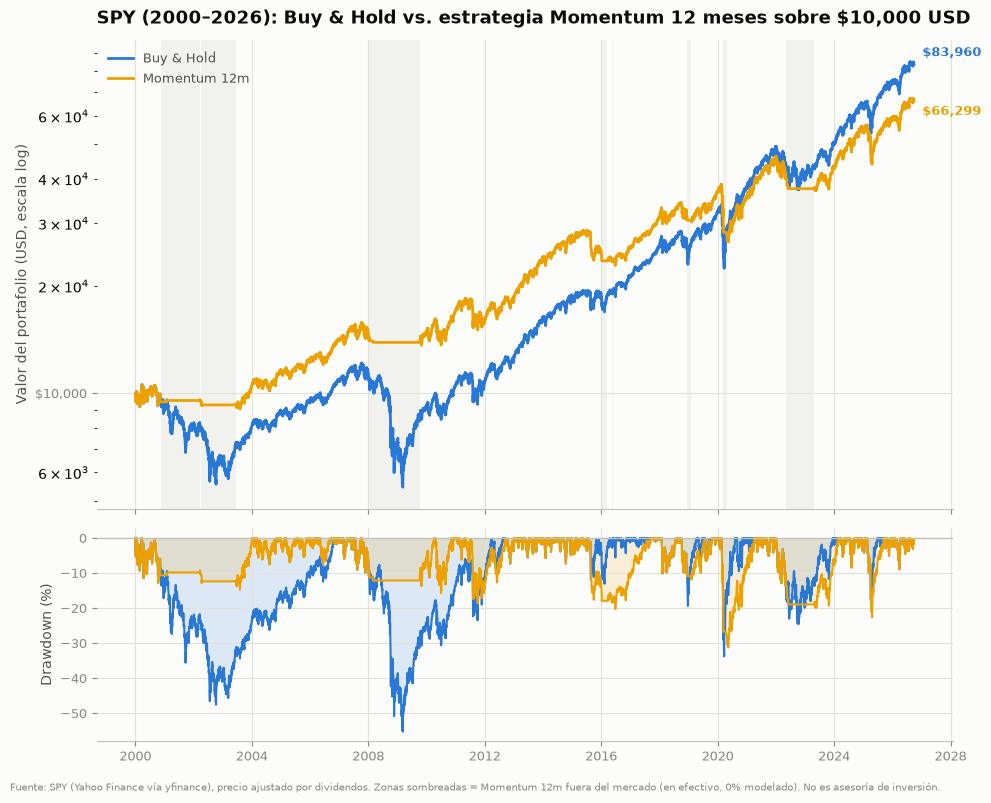

In [6]:
series_momentum = pd.DataFrame({
    "fecha": df_momentum["fecha"],
    "valor_buy_and_hold": valor_bh.values,
    "valor_momentum": valor_momentum.values,
    "posicion_momentum": df_momentum["posicion"].values,
})
series_momentum.to_csv("../outputs/series/series_comparacion_momentum.csv", index=False)
resumen_momentum.to_csv("../outputs/metrics/resumen_metricas_momentum.csv", index=False)

viz.graficar_estrategia_vs_benchmark(
    series_momentum, "valor_buy_and_hold", "valor_momentum", "posicion_momentum",
    viz.COLOR_MOMENTUM, "Momentum 12m",
    "SPY (2000–2026): Buy & Hold vs. estrategia Momentum 12 meses sobre $10,000 USD",
    "../outputs/figures/comparacion_buyhold_vs_momentum.png",
)

## RSI(14) 30/70

Distinto en espíritu a las dos anteriores: **reversión a la media** (contrarian), no tendencia. Entra en sobreventa (RSI cruza por debajo de 30), sale en sobrecompra (RSI cruza por arriba de 70), con histéresis (mantiene posición entre cruces). RSI calculado con el suavizado de Wilder (método clásico).

In [7]:
señal_rsi = strategies.señal_rsi(spy)
df_rsi = backtest.recortar_periodo(spy, señal_rsi, FECHA_INICIO_ANALISIS)
df_rsi, valor_rsi = backtest.simular(df_rsi, CAPITAL_TOTAL)

resumen_rsi = pd.DataFrame([
    backtest.resumen(df_bh, valor_bh, CAPITAL_TOTAL, "Buy & Hold (SPY, mismos datos)"),
    backtest.resumen(df_rsi, valor_rsi, CAPITAL_TOTAL, "RSI(14) 30/70"),
])
resumen_rsi

,Escenario,Valor final (USD),CAGR,Drawdown máximo,Sharpe (rf=0),Sortino (rf=0),Operaciones,% tiempo invertido
0,"Buy & Hold (SPY, mismos datos)",83960.499077,0.082772,-0.551895,0.510584,0.650008,0,0.999851
1,RSI(14) 30/70,27996.578177,0.039227,-0.551895,0.320929,0.260651,46,0.364907


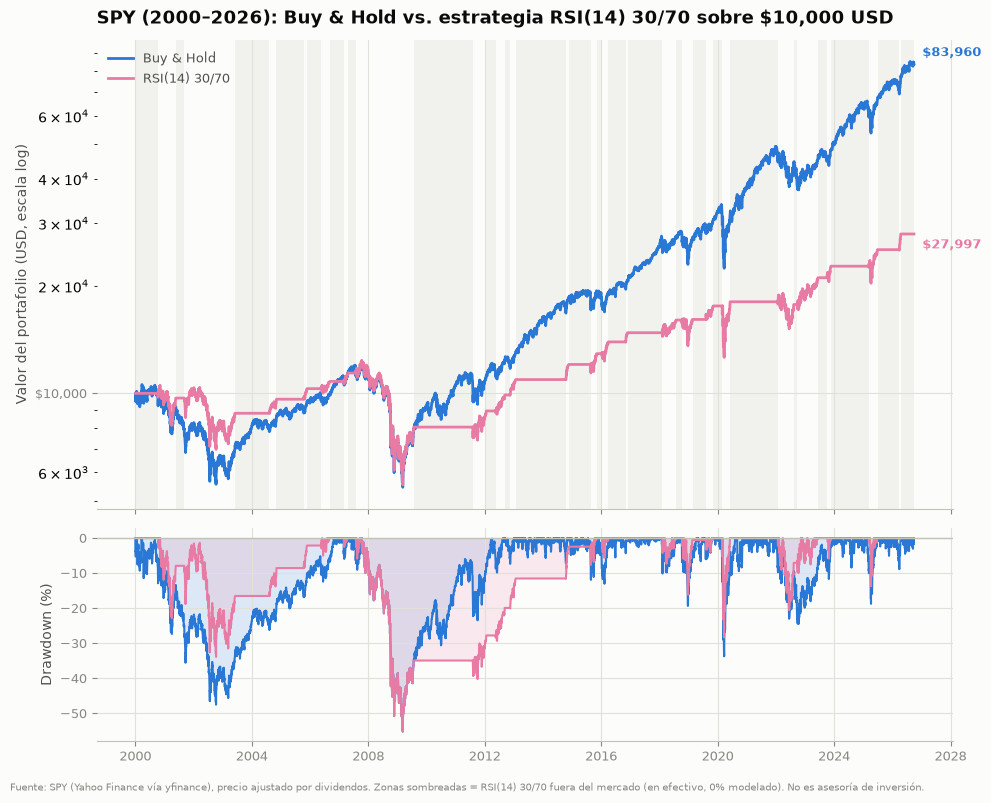

In [8]:
series_rsi = pd.DataFrame({
    "fecha": df_rsi["fecha"],
    "valor_buy_and_hold": valor_bh.values,
    "valor_rsi": valor_rsi.values,
    "posicion_rsi": df_rsi["posicion"].values,
})
series_rsi.to_csv("../outputs/series/series_comparacion_rsi.csv", index=False)
resumen_rsi.to_csv("../outputs/metrics/resumen_metricas_rsi.csv", index=False)

viz.graficar_estrategia_vs_benchmark(
    series_rsi, "valor_buy_and_hold", "valor_rsi", "posicion_rsi",
    viz.COLOR_RSI, "RSI(14) 30/70",
    "SPY (2000–2026): Buy & Hold vs. estrategia RSI(14) 30/70 sobre $10,000 USD",
    "../outputs/figures/comparacion_buyhold_vs_rsi.png",
)

### Hallazgo: el RSI se quedó atrapado en la crisis de 2008

El RSI compró en la caída de 2008 (sobreventa) y **nunca recibió señal de salida durante toda la crisis** — el RSI se quedó deprimido sin volver a cruzar 70 mientras el precio seguía cayendo. Se puede confirmar comparando la fecha del drawdown máximo de ambas series:

In [9]:
pico_bh_ = series_rsi["valor_buy_and_hold"].cummax()
dd_bh_ = (series_rsi["valor_buy_and_hold"] - pico_bh_) / pico_bh_
pico_rsi_ = series_rsi["valor_rsi"].cummax()
dd_rsi_ = (series_rsi["valor_rsi"] - pico_rsi_) / pico_rsi_

print("Fecha drawdown máximo Buy & Hold:", series_rsi.loc[dd_bh_.idxmin(), "fecha"].date(), f"({dd_bh_.min():.2%})")
print("Fecha drawdown máximo RSI:       ", series_rsi.loc[dd_rsi_.idxmin(), "fecha"].date(), f"({dd_rsi_.min():.2%})")

Fecha drawdown máximo Buy & Hold: 2009-03-09 (-55.19%)
Fecha drawdown máximo RSI:        2009-03-09 (-55.19%)


Es una lección real sobre el riesgo de "comprar el cuchillo cayendo" con una regla de reversión sin stop-loss: sobreventa no garantiza rebote, y una señal de entrada sin una de salida robusta puede dejar atrapado el capital en toda una caída.

## Cierre: las 4 estrategias juntas

In [10]:
resumen_todas = pd.concat([
    resumen_sma.iloc[[0]],   # Buy & Hold (una sola vez)
    resumen_sma.iloc[[1]],
    resumen_momentum.iloc[[1]],
    resumen_rsi.iloc[[1]],
], ignore_index=True)

series_todas = series_sma[["fecha", "valor_buy_and_hold", "valor_sma"]].merge(
    series_momentum[["fecha", "valor_momentum"]], on="fecha"
).merge(
    series_rsi[["fecha", "valor_rsi"]], on="fecha"
)

resumen_todas.to_csv("../outputs/metrics/resumen_metricas_todas.csv", index=False)
series_todas.to_csv("../outputs/series/series_comparacion_todas.csv", index=False)
resumen_todas

,Escenario,Valor final (USD),CAGR,Drawdown máximo,Sharpe (rf=0),Sortino (rf=0),Operaciones,% tiempo invertido
0,"Buy & Hold (SPY, mismos datos)",83960.499077,0.082772,-0.551895,0.510584,0.650008,0,0.999851
1,SMA 50/200,81612.159323,0.081624,-0.337173,0.654399,0.696106,26,0.738290
2,Momentum 12m,66298.515971,0.073256,-0.311682,0.599340,0.647028,90,0.778885
3,RSI(14) 30/70,27996.578177,0.039227,-0.551895,0.320929,0.260651,46,0.364907


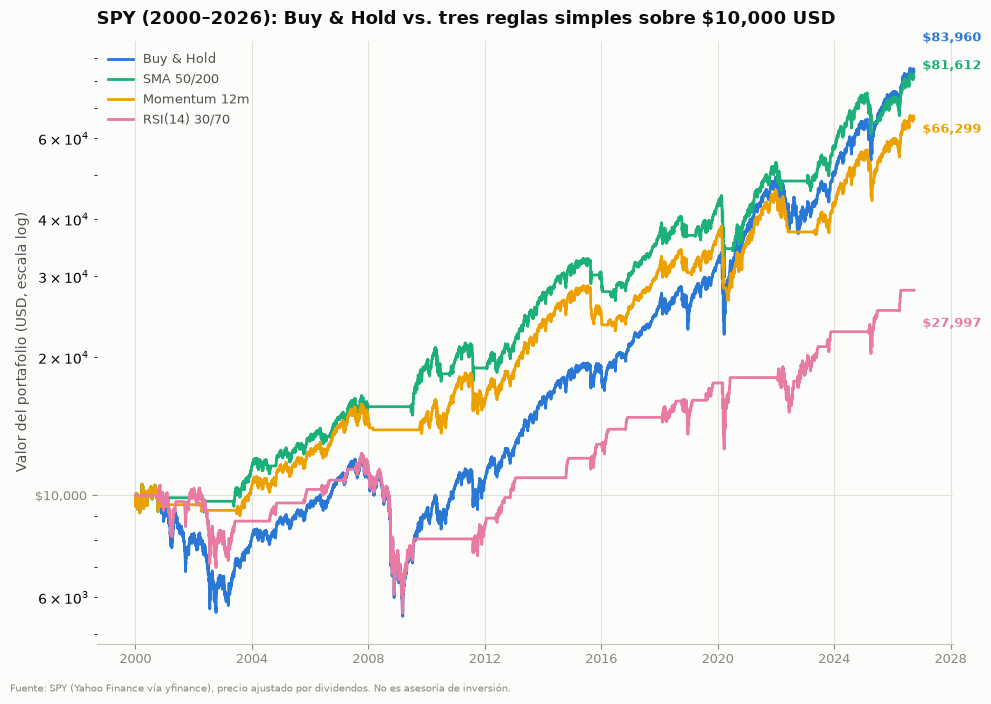

In [11]:
viz.graficar_todas_las_estrategias(
    series_todas,
    series=[
        ("valor_buy_and_hold", viz.COLOR_BUY_AND_HOLD, "Buy & Hold"),
        ("valor_sma", viz.COLOR_SMA, "SMA 50/200"),
        ("valor_momentum", viz.COLOR_MOMENTUM, "Momentum 12m"),
        ("valor_rsi", viz.COLOR_RSI, "RSI(14) 30/70"),
    ],
    titulo="SPY (2000–2026): Buy & Hold vs. tres reglas simples sobre $10,000 USD",
    archivo_salida="../outputs/figures/comparacion_todas_estrategias.png",
)

## Lectura general

Las dos reglas de tendencia (SMA, Momentum) mejoran el perfil de riesgo (menor drawdown, mejor Sharpe/Sortino) a cambio de algo de rendimiento total — un trade-off razonable, en la línea del benchmark del Paso 1. La regla de reversión (RSI) fue la peor de las tres en todas las métricas: ni protegió en la crisis de 2008 ni generó rendimiento competitivo.

**Ninguna de las tres le gana a Buy & Hold en rendimiento absoluto todavía**, y sigue sin haber comisiones, slippage ni impuestos modelados. Este conjunto de 4 curvas es el punto de comparación para la Fase 3, Paso 3 (ML clásico).